# Machine Learning — Practical P04: Trees and Ensembles: Complexity and Generalization

**Course:** Machine Learning · National University of Kyiv-Mohyla Academy (NaUKMA)  
**Instructor:** Dmytro Kuzmenko · kuzmenko@ukma.edu.ua  
**Module:** 4. Trees and Ensembles · **Week 4**  
**Workload:** one practical class ≈ 1.5–2 hours of active work, including discussion  
**Status:** NOT graded — practicals are skill-development and exam-preparation sessions.  
**Prerequisites:** decision trees, train/validation split, accuracy, feature matrices

### How to work with this notebook

Every consequential task follows the loop **Experiment → Decision → Evidence → Interpretation → Counterfactual**.  
Scaffolding cells are already written and executed: read them, run them mentally, and use the printed numbers and plots as evidence.  
Empty cells are yours — they contain no model answers. The discussion questions are meant to be talked through in class.


### Learning objectives
- Find where a decision tree starts to overfit using a depth–accuracy curve.
- Explain how random forests and boosting reduce variance/bias compared with a single tree.
- Interpret feature importances critically, including the correlated-features pitfall.

## Warm-up (diagnostic)



**Warm-up 1.** A decision tree with `max_depth=40` reaches **train accuracy 1.00** and
**validation accuracy 0.62**. Give a one-sentence diagnosis and name two levers you would pull first.


**Your answer:**

**Warm-up 2.** Which predictor's decision boundary is more sensitive to a small change in the training
data: a single deep tree, or a random forest of 500 trees?

- (a) the single tree
- (b) the random forest
- (c) they are equally sensitive
- (d) depends only on the dataset size, not the model


**Your answer:**

**Warm-up 3.** True or false: in boosting, trees are trained *sequentially*, and each new tree focuses
on the mistakes of the current ensemble (for example, via sample weights or residuals).


**Your answer:**

## Guided Exercise — depth, forests, boosting, importances

Synthetic classification with 10 features (2 informative, 8 noise). This lets us watch overfitting and
the variance-reduction effect of ensembles without any downloads.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

np.random.seed(42)
%matplotlib inline

X, y = make_classification(n_samples=800, n_features=10, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, flip_y=0.08, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"train: {len(X_tr)}, validation: {len(X_va)}")


train: 560, validation: 240


### Task 1: Depth vs generalization

**Experiment.** Fit decision trees with depth 1..25 (no other constraints) and record train and
validation accuracy.


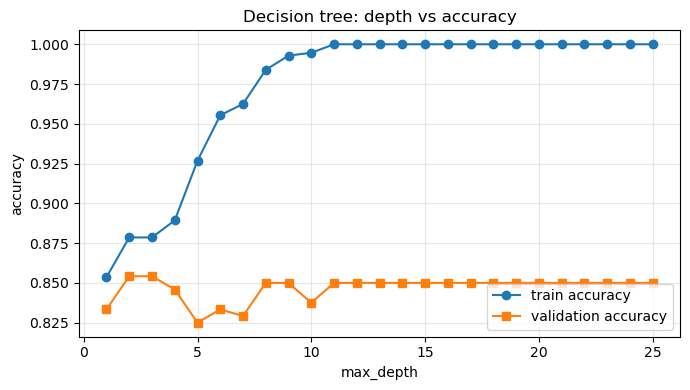

In [2]:
depths = np.arange(1, 26)
tr_acc, va_acc = [], []
for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_tr, y_tr)
    tr_acc.append(accuracy_score(y_tr, tree.predict(X_tr)))
    va_acc.append(accuracy_score(y_va, tree.predict(X_va)))

plt.figure(figsize=(7, 4))
plt.plot(depths, tr_acc, "o-", label="train accuracy")
plt.plot(depths, va_acc, "s-", label="validation accuracy")
plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.title("Decision tree: depth vs accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Evidence.** Training accuracy rises monotonically; validation accuracy peaks and then declines —
the textbook overfitting curve, now with real numbers.

**Decision.** Which depth would you pick, and what evidence (not intuition) supports the choice?
**Interpretation.** Why does validation accuracy *fall* at large depth when the tree can already fit the
training data at depth ≈ 6?

**Counterfactual.** If the dataset had 8 informative features instead of 2, predict how the optimal
depth and the size of the overfitting drop would change.


**Your answer:**

### Task 2: Single tree vs random forest

**Experiment.** Compare a fully-grown single tree with a random forest (200 trees) and repeat both over
10 different random splits to see stability.


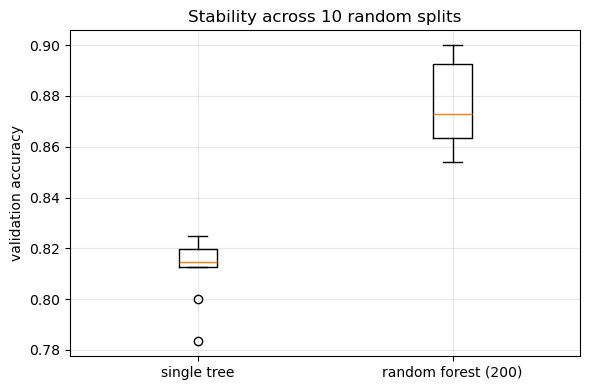

single tree: mean 0.812 ± 0.012
random forest: mean 0.876 ± 0.016


In [3]:
rng = np.random.RandomState(0)
tree_va, rf_va = [], []
for seed in range(10):
    Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.3, random_state=seed)
    t = DecisionTreeClassifier(random_state=seed).fit(Xt, yt)
    rf = RandomForestClassifier(n_estimators=200, random_state=seed, n_jobs=-1).fit(Xt, yt)
    tree_va.append(accuracy_score(yv, t.predict(Xv)))
    rf_va.append(accuracy_score(yv, rf.predict(Xv)))

plt.figure(figsize=(6, 4))
plt.boxplot([tree_va, rf_va], tick_labels=["single tree", "random forest (200)"])
plt.ylabel("validation accuracy")
plt.title("Stability across 10 random splits")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"single tree: mean {np.mean(tree_va):.3f} ± {np.std(tree_va):.3f}")
print(f"random forest: mean {np.mean(rf_va):.3f} ± {np.std(rf_va):.3f}")


**Evidence.** The forest scores higher on average *and* varies less across splits.

**Interpretation.** Random forests average many decorrelated trees — which component of the
bias–variance decomposition does this attack, and what is the price you pay compared with a single
tree?

**Counterfactual.** Predict what happens to the forest's validation accuracy if `n_estimators` were 5,
and why (think about the law of large numbers).


**Your answer:**

### Task 3: Boosting — sequential correction

**Experiment.** Compare a single deep tree, a random forest, and a gradient-boosted ensemble of shallow
trees on the same fixed split.


In [4]:
tree = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=0.1, random_state=42).fit(X_tr, y_tr)

for name, m in [("single tree (unconstrained)", tree), ("random forest (200)", rf),
                ("gradient boosting (100 x depth-2)", gb)]:
    print(f"{name:<32} train {accuracy_score(y_tr, m.predict(X_tr)):.3f} | "
          f"validation {accuracy_score(y_va, m.predict(X_va)):.3f}")


single tree (unconstrained)      train 1.000 | validation 0.850
random forest (200)              train 1.000 | validation 0.863
gradient boosting (100 x depth-2) train 0.934 | validation 0.867


**Interpretation.** Boosting uses *shallow* trees but many of them, each correcting the ensemble's
residual errors. What would you expect if `n_estimators` were 5,000 and `max_depth` were 10 — and how
would you detect it (which two numbers)?

**Decision.** You must choose one of the three for a small dataset with noisy labels. Which one, and
what is the main risk of your choice?


**Your answer:**

### Task 4: Feature-importance caveats with correlated features

**Experiment.** Build a dataset where feature 1 is informative, feature 2 is a *noisy copy* of feature 1,
and feature 3 is pure noise. Fit a random forest and look at (a) tree-based importances and
(b) permutation importances.


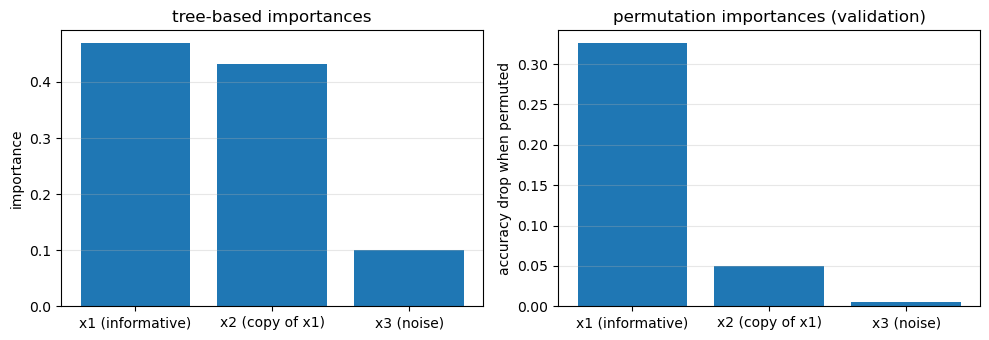

tree-based:     x1 0.469 | x2 0.432 | x3 0.100
permutation:    x1 0.326 | x2 0.050 | x3 0.006


In [5]:
rng = np.random.RandomState(5)
n = 600
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(0, 0.3, size=n)          # correlated copy of x1
x3 = rng.normal(size=n)                       # irrelevant noise
Xc = np.column_stack([x1, x2, x3])
yc = (x1 + 0.5 * x2 + rng.normal(0, 0.5, size=n) > 0).astype(int)

Xc_tr, Xc_va, yc_tr, yc_va = train_test_split(Xc, yc, test_size=0.3, random_state=42)
rf_c = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(Xc_tr, yc_tr)

tree_imp = rf_c.feature_importances_
perm = permutation_importance(rf_c, Xc_va, yc_va, n_repeats=20, random_state=42)
perm_mean = perm.importances_mean

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(["x1 (informative)", "x2 (copy of x1)", "x3 (noise)"], tree_imp)
axes[0].set_title("tree-based importances")
axes[0].set_ylabel("importance")
axes[1].bar(["x1 (informative)", "x2 (copy of x1)", "x3 (noise)"], perm_mean)
axes[1].set_title("permutation importances (validation)")
axes[1].set_ylabel("accuracy drop when permuted")
for ax in axes:
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print(f"tree-based:     x1 {tree_imp[0]:.3f} | x2 {tree_imp[1]:.3f} | x3 {tree_imp[2]:.3f}")
print(f"permutation:    x1 {perm_mean[0]:.3f} | x2 {perm_mean[1]:.3f} | x3 {perm_mean[2]:.3f}")


**Evidence.** The two correlated informative features split the tree-based importance almost equally
(0.47 / 0.43) — a naive reader would conclude both are equally valuable. Permutation importance tells a
different story: feature 1 is the primary carrier (0.33), feature 2 adds little once feature 1 is
present (0.05), and the noise feature contributes nothing (0.006).

**Interpretation.** Feature importances from trees reflect *split usage*, not causal effect. What
conclusion would a naive reader draw from the tree-based plot, and why is it wrong?

**Counterfactual.** If x2 were *exactly identical* to x1 (correlation 1.0), predict the tree-based
importances of x1 and x2. Then verify by re-running the snippet with `x2 = x1` in your own code cell if
you want.


**Your answer:**

## Discussion Questions

1. Trees partition the feature space greedily. In one sentence each: what does `max_depth` limit, what
   does `min_samples_leaf` limit, and which one attacks overfitting more directly?
2. Why do random forests need *decorrelated* trees (random feature subsets, bootstrap samples) to beat a
   single tree — wouldn't averaging identical trees be just as good?
3. Boosting reduces bias more than variance. What happens to the *gap* (train − validation) when you
   add many more boosting iterations, and how does that differ from adding trees to a random forest?
4. Give two concrete mechanisms by which a *useless* feature can still receive a large tree-based
   importance. How would you verify its usefulness?
5. When is a single interpretable tree preferable to a random forest, despite lower accuracy?
6. `flip_y=0.08` added label noise to this dataset. How does label noise shift the depth–accuracy curve
   and the achievable validation accuracy?


## Challenge — why does a "useless" feature look important?

**Scenario.** A colleague adds a feature `age_duplicate = age + tiny noise` (correlation with `age`
≈ 0.999) to a model for predicting a health outcome, and reports a tree-based importance plot where
`age_duplicate` appears in the top-3. The colleague concludes the new feature is valuable.

**Experiment.** Run the code below: it builds exactly this situation and prints the tree-based
importance plot you must interpret.


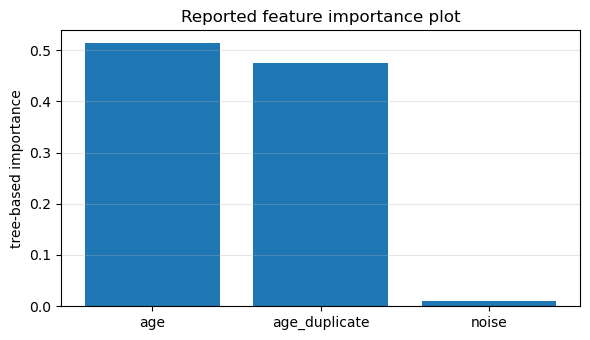

importances: age 0.513 | age_duplicate 0.476 | noise 0.011


In [6]:
rng = np.random.RandomState(9)
n = 500
age = rng.normal(50, 12, size=n)
age_dup = age + rng.normal(0, 0.2, size=n)          # near-duplicate feature
noise_f = rng.normal(size=n)
Xh = np.column_stack([age, age_dup, noise_f])
yh = (age > 52).astype(int)

Xh_tr, Xh_va, yh_tr, yh_va = train_test_split(Xh, yh, test_size=0.3, random_state=42)
rf_h = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(Xh_tr, yh_tr)
imp = rf_h.feature_importances_
plt.figure(figsize=(6, 3.5))
plt.bar(["age", "age_duplicate", "noise"], imp)
plt.ylabel("tree-based importance")
plt.title("Reported feature importance plot")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
print(f"importances: age {imp[0]:.3f} | age_duplicate {imp[1]:.3f} | noise {imp[2]:.3f}")


**Your task (interpretation + verification plan).**
1. Explain why `age_duplicate` appears important even though it carries almost no *new* information.
2. Predict what would happen to the importances of `age` and `age_duplicate` if the noise were exactly
   zero (identical columns).
3. Propose a verification that settles whether the duplicate feature adds real predictive value —
   name the method (e.g., permutation importance, drop-one retraining) and predict its outcome.
4. (Optional) Implement your verification in the code cell.


In [7]:
# Your code here — optional verification (permutation importance or drop-one retraining)


**Your answer (explanation and verification plan):**

## Takeaways

- The depth–accuracy curve turns overfitting in trees into a visible fact: pick depth where validation
  accuracy peaks, not where train accuracy saturates.
- A single unconstrained tree has high variance; random forests reduce variance by averaging
  decorrelated trees, at the cost of some interpretability and speed.
- Boosting sequentially corrects residuals with shallow trees; its failure mode is overfitting when the
  number of iterations grows too large — watch the train–validation gap.
- Tree-based feature importances measure split usage, not causal or unique contribution.
- Correlated features split importance between themselves: a "useless" duplicate can look important and
  an important feature can look useless. Use permutation importance or drop-one retraining to check.
- Constrain complexity (depth, min_samples_leaf, n_estimators, learning rate) and validate on data the
  model never saw during fitting.
